# S11: Pipeline de limpieza y transformación

Daniel Pallares

Este notebook encadena en un solo recorrido las cinco etapas de la Misión 2. Carga un único archivo de entrada, el dataset con la imputación inicial de la Semana 4, y produce un único archivo de salida con todas las columnas de las cinco etapas. No lee ni escribe archivos intermedios, así que cualquier persona puede correrlo de principio a fin y llegar exactamente al mismo resultado.

Las etapas son limpieza de inconsistencias y duplicados, tratamiento de atípicos y ruido, escalado de variables numéricas, codificación de variables categóricas y transformaciones de fecha, texto y variables sesgadas.

## Configuración y carga del punto de partida

In [1]:
import importlib.util
import subprocess
import sys

# scikit-learn y category_encoders no siempre vienen instalados; se instalan solo si faltan,
# antes de cualquier import, para que el notebook corra completo en cualquier maquina
for modulo, paquete in [("sklearn", "scikit-learn"), ("category_encoders", "category_encoders")]:
    if importlib.util.find_spec(modulo) is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", paquete], check=True)

import pandas as pd
import numpy as np
import unicodedata
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)

RANDOM_STATE = 42

df = pd.read_csv('../S04_PD_Pallares_DatasetImputacionInicial.csv')
N = len(df)
print(f"Punto de partida: {N:,} filas | {df.shape[1]} columnas")
df.head(3)

Punto de partida: 640,000 filas | 25 columnas


,id_pedido,id_cliente,fecha_pedido,canal_compra,metodo_pago,ciudad_tienda,codigo_postal,categoria_producto,producto,precio_unitario,unidades_vendidas,monto_compra,edad_cliente,correo_cliente,nivel_satisfaccion,nivel_lealtad,comentario_cliente,peso_pedido_kg,fecha_actualizacion_stock,fuga_cliente,precio_monto_imputado,nivel_satisfaccion_imputado,ciudad_tienda_imputado,correo_cliente_imputado,comentario_cliente_imputado
0,P505195,C45650,15/11/2025,Tienda,Efectivo,bogota,1100103,Moda,Chaqueta impermeable,28700.0,1,28700.0,32,cliente405195@novamarket.com.co,Bajo,Platino,El domiciliario fue muy amable,14.9,2026-04-17,0,False,False,False,False,False
1,P677836,C84260,2026-03-05,Web,Efectivo,MZL,1700101,Electrónica,Parlante bluetooth,195700.0,2,391400.0,73,cliente577836@yahoo.es,Medio,Bronce,El producto llegó dañado,12.9,2026-06-10,0,False,False,False,False,False
2,P387869,C164166,2025-03-13,Tienda,PayPal,Cúcuta,5400101,Juguetería,Rompecabezas 1000 piezas,597600.0,-3,-1792800.0,32,cliente287869@novamarket.com.co,Bajo,Oro,El domiciliario fue muy amable,14.3,2026-02-26,0,False,False,False,False,False


## Etapa 1: Limpieza de inconsistencias y duplicados

Esta etapa deja cada columna de texto con una sola forma de escritura por valor, convierte `fecha_pedido` a un tipo de fecha real y elimina los duplicados exactos. No crea columnas nuevas, solo corrige las que ya existen.

In [2]:
columnas_texto = ['canal_compra', 'metodo_pago', 'categoria_producto', 'ciudad_tienda']

# se guarda ANTES de tocar nada, para poder confirmar mas adelante que la limpieza
# no introdujo nulos nuevos por accidente
nulos_antes_texto = df[columnas_texto].isna().sum()

for col in columnas_texto:
    df[col] = df[col].str.strip().str.title()

for col in columnas_texto:
    print(f"{col}: {df[col].nunique(dropna=True)} valores unicos tras strip()+title()")

canal_compra: 4 valores unicos tras strip()+title()
metodo_pago: 4 valores unicos tras strip()+title()
categoria_producto: 8 valores unicos tras strip()+title()
ciudad_tienda: 33 valores unicos tras strip()+title()


In [3]:
def normaliza_texto(s):
    # Quita tildes/errores de encoding, espacios sobrantes y mayusculas para poder comparar variantes
    if pd.isna(s):
        return s
    return unicodedata.normalize('NFKD', str(s)).encode('ascii', 'ignore').decode().strip().lower()

# --- categoria_producto: una vez sin tildes rotas, cada categoria cae en una sola forma ---
mapa_categoria = {
    'belleza': 'Belleza', 'deportes': 'Deportes', 'electronica': 'Electronica',
    'hogar': 'Hogar', 'jugueteria': 'Jugueteria', 'moda': 'Moda',
}
df['categoria_producto'] = df['categoria_producto'].apply(normaliza_texto).map(mapa_categoria)

# --- ciudad_tienda: ademas de tildes rotas, hay abreviaturas de 3 letras, sufijos
# administrativos y variantes de escritura que no se resuelven solo quitando tildes ---
abreviaturas_ciudad = {
    'ctg': 'cartagena', 'baq': 'barranquilla', 'bga': 'bucaramanga', 'mde': 'medellin',
    'mzl': 'manizales', 'smr': 'santa marta', 'bog': 'bogota',
}

def normaliza_ciudad(s):
    if pd.isna(s):
        return s
    s2 = normaliza_texto(s).replace(',', ' ')
    for sufijo in [' d.c.', ' dc', ' ant.', ' caldas']:
        s2 = s2.replace(sufijo, '')
    s2 = s2.replace('b/quilla', 'barranquilla').replace('b/manga', 'bucaramanga')
    s2 = s2.replace('santiago de cali', 'cali').replace('cartagena de indias', 'cartagena')
    s2 = s2.replace('santamarta', 'santa marta').replace('sta. marta', 'santa marta').replace('sta marta', 'santa marta')
    s2 = ' '.join(s2.split())
    return abreviaturas_ciudad.get(s2, s2)

mapa_ciudad = {
    'bogota': 'Bogota', 'medellin': 'Medellin', 'cali': 'Cali', 'barranquilla': 'Barranquilla',
    'cartagena': 'Cartagena', 'bucaramanga': 'Bucaramanga', 'pereira': 'Pereira',
    'manizales': 'Manizales', 'ibague': 'Ibague', 'cucuta': 'Cucuta',
    'villavicencio': 'Villavicencio', 'santa marta': 'Santa Marta',
}
df['ciudad_tienda'] = df['ciudad_tienda'].apply(normaliza_ciudad).map(mapa_ciudad)

# correccion puntual del nombre de marca que title() dejo mal escrito
df['metodo_pago'] = df['metodo_pago'].replace('Paypal', 'PayPal')

for col in columnas_texto:
    print(f"{col}: {df[col].nunique(dropna=True)} valores unicos ->", sorted(df[col].dropna().unique()))

canal_compra: 4 valores unicos -> ['App', 'Marketplace', 'Tienda', 'Web']
metodo_pago: 4 valores unicos -> ['Efectivo', 'PayPal', 'Tarjeta', 'Transferencia']
categoria_producto: 6 valores unicos -> ['Belleza', 'Deportes', 'Electronica', 'Hogar', 'Jugueteria', 'Moda']
ciudad_tienda: 12 valores unicos -> ['Barranquilla', 'Bogota', 'Bucaramanga', 'Cali', 'Cartagena', 'Cucuta', 'Ibague', 'Manizales', 'Medellin', 'Pereira', 'Santa Marta', 'Villavicencio']


In [4]:
for col in columnas_texto:
    assert df[col].nunique(dropna=True) in (4, 6, 12), f"{col} no quedo en su numero de categorias esperado"

nulos_despues_texto = df[columnas_texto].isna().sum()
diferencia = nulos_despues_texto - nulos_antes_texto
assert (diferencia == 0).all(), "La normalizacion introdujo nulos nuevos que no estaban en el dataset original"
print("OK: ninguna columna de texto gano nulos nuevos durante la limpieza.")

OK: ninguna columna de texto gano nulos nuevos durante la limpieza.


`fecha_pedido` llega como texto y con dos formatos distintos mezclados, algunos con el mes escrito en palabras. Se traducen los nombres de mes a número y se prueban los dos formatos de forma explícita, sin dejar que pandas adivine.

In [5]:
meses_es = {
    'enero': '01', 'febrero': '02', 'marzo': '03', 'abril': '04', 'mayo': '05', 'junio': '06',
    'julio': '07', 'agosto': '08', 'septiembre': '09', 'setiembre': '09', 'octubre': '10',
    'noviembre': '11', 'diciembre': '12',
}

fecha_pedido_texto = df['fecha_pedido'].astype(str).str.lower()
for mes_nombre, mes_numero in meses_es.items():
    fecha_pedido_texto = fecha_pedido_texto.str.replace(mes_nombre, mes_numero, regex=False)

nulos_antes_fecha = df['fecha_pedido'].isna().sum()

# se prueban los 2 formatos aceptados de forma explicita (nunca se deja que pandas "adivine")
fecha_iso = pd.to_datetime(fecha_pedido_texto, format='%Y-%m-%d', errors='coerce')
fecha_dmy = pd.to_datetime(fecha_pedido_texto, format='%d/%m/%Y', errors='coerce')
df['fecha_pedido'] = fecha_iso.fillna(fecha_dmy)

nulos_despues_fecha = df['fecha_pedido'].isna().sum()
print(f"fecha_pedido vacios ANTES de convertir (texto): {nulos_antes_fecha:,}")
print(f"fecha_pedido vacios (NaT) DESPUES de convertir a fecha real: {nulos_despues_fecha:,} ({nulos_despues_fecha/N*100:.2f}%)")
print(f"dtype final de fecha_pedido: {df['fecha_pedido'].dtype}")

fecha_pedido vacios ANTES de convertir (texto): 0
fecha_pedido vacios (NaT) DESPUES de convertir a fecha real: 22,687 (3.54%)
dtype final de fecha_pedido: datetime64[ns]


In [6]:
print("Filas antes de eliminar duplicados exactos:", f"{len(df):,}")
df = df.drop_duplicates(keep='first').reset_index(drop=True)
print("Filas despues de eliminar duplicados exactos:", f"{len(df):,}")

Filas antes de eliminar duplicados exactos: 640,000
Filas despues de eliminar duplicados exactos: 620,000


In [7]:
placeholder = 'sin_registro@desconocido.com'
con_correo_post = df['correo_cliente'].notna()

dup_exactos_post = df.duplicated().sum()
subset_pedido_equivalente = ['correo_cliente', 'fecha_pedido', 'producto', 'monto_compra']
duplicados_encubiertos = df[con_correo_post & (df['correo_cliente'] != placeholder)].duplicated(subset=subset_pedido_equivalente, keep=False).sum()

assert dup_exactos_post == 0, "Quedaron duplicados exactos sin eliminar"
assert duplicados_encubiertos == 0, "Hay pedidos que parecen el mismo evento repetido bajo un id_pedido distinto"
print(f"OK: no quedan duplicados exactos ni duplicados encubiertos. Etapa 1 cierra con {len(df):,} filas.")

OK: no quedan duplicados exactos ni duplicados encubiertos. Etapa 1 cierra con 620,000 filas.


## Etapa 2: Tratamiento de valores atípicos y ruido

Aquí se separan dos cosas que no se tratan igual. Por un lado los errores de captura, que son valores imposibles y se eliminan. Por otro los montos altos legítimos, que se conservan o se capan según el número de unidades del pedido.

Los valores centinela se identificaron en la Semana 7 mirando la distribución, y son los que aparecen abajo como grupos.

In [8]:
sentinel_unidades = [-3, -1, 0, 5000, 9999]
sentinel_precio = [50_000_000.0, 999_000_000.0]

grupo_negativo = df['monto_compra'] < 0
grupo_precio_centinela = df['precio_unitario'].isin(sentinel_precio)
grupo_unidades_centinela = df['unidades_vendidas'].isin(sentinel_unidades)

print(f"Grupo 1 - monto_compra negativo: {grupo_negativo.sum():,}")
print(f"Grupo 2 - precio_unitario centinela (50,000,000 o 999,000,000): {grupo_precio_centinela.sum():,}")
print(f"Grupo 3 - unidades_vendidas centinela (0, 5000, 9999, -1, -3): {grupo_unidades_centinela.sum():,}")

Grupo 1 - monto_compra negativo: 35,650
Grupo 2 - precio_unitario centinela (50,000,000 o 999,000,000): 6,000
Grupo 3 - unidades_vendidas centinela (0, 5000, 9999, -1, -3): 45,000


In [9]:
mascara_error = grupo_negativo | grupo_precio_centinela | grupo_unidades_centinela
filas_antes = len(df)
print(f"Filas marcadas como error de captura: {mascara_error.sum():,} ({mascara_error.sum()/filas_antes*100:.2f}%)")

df_tratado = df[~mascara_error].copy().reset_index(drop=True)
print(f"Filas antes de tratar: {filas_antes:,}")
print(f"Filas despues de eliminar errores de captura: {len(df_tratado):,}")

Filas marcadas como error de captura: 68,210 (11.00%)
Filas antes de tratar: 620,000
Filas despues de eliminar errores de captura: 551,790


Los límites del IQR se recalculan sobre los datos ya sin errores de captura. Calcularlos antes daría un límite inflado por los valores centinela, que no representan compras reales.

In [10]:
Q1_t = df_tratado['monto_compra'].quantile(0.25)
Q3_t = df_tratado['monto_compra'].quantile(0.75)
IQR_t = Q3_t - Q1_t
limite_inferior_t = Q1_t - 1.5 * IQR_t
limite_superior_t = Q3_t + 1.5 * IQR_t

print(f"Q1 = {Q1_t:,.0f}   Q3 = {Q3_t:,.0f}   IQR = {IQR_t:,.0f}")
print(f"limite_inferior = {limite_inferior_t:,.0f}")
print(f"limite_superior = {limite_superior_t:,.0f}")

restantes = df_tratado[df_tratado['monto_compra'] > limite_superior_t]
print(f"\nFilas que siguen por encima del limite superior: {len(restantes):,}")
print("\nunidades_vendidas de esas filas:")
print(restantes['unidades_vendidas'].value_counts().sort_index())

Q1 = 268,600   Q3 = 829,000   IQR = 560,400
limite_inferior = -572,000
limite_superior = 1,669,600

Filas que siguen por encima del limite superior: 37,552

unidades_vendidas de esas filas:
unidades_vendidas
2      840
3    11891
4    12511
5    12310
Name: count, dtype: int64


Los pedidos que superan el límite se reparten en dos comportamientos distintos. Los de 4 y 5 unidades se ven como ventas de alto valor reales, así que se conservan y se marcan. Los de 2 y 3 unidades tienen un monto que no cuadra con esa cantidad, así que se capan hasta el límite superior.

In [11]:
es_corporativa = (df_tratado['monto_compra'] > limite_superior_t) & (df_tratado['unidades_vendidas'].isin([4, 5]))
a_capar = (df_tratado['monto_compra'] > limite_superior_t) & (df_tratado['unidades_vendidas'].isin([2, 3]))

print(f"Filas a mantener y marcar como venta de alto valor: {es_corporativa.sum():,}")
print(f"Filas a capar (winsorizing): {a_capar.sum():,}")

df_tratado['es_venta_corporativa'] = es_corporativa

media_antes = df_tratado.loc[a_capar, 'monto_compra'].mean()
std_antes = df_tratado['monto_compra'].std()

df_tratado['monto_compra_capado'] = False
df_tratado.loc[a_capar, 'monto_compra'] = df_tratado.loc[a_capar, 'monto_compra'].clip(upper=limite_superior_t)
df_tratado.loc[a_capar, 'monto_compra_capado'] = True

media_despues = df_tratado.loc[a_capar, 'monto_compra'].mean()
std_despues = df_tratado['monto_compra'].std()

print(f"\nGrupo capado - media de monto_compra antes: {media_antes:,.0f}  |  despues: {media_despues:,.0f}")
print(f"monto_compra (dataset completo) - desviacion estandar antes: {std_antes:,.0f}  |  despues: {std_despues:,.0f}")

Filas a mantener y marcar como venta de alto valor: 24,821
Filas a capar (winsorizing): 12,731

Grupo capado - media de monto_compra antes: 1,994,209  |  despues: 1,669,600
monto_compra (dataset completo) - desviacion estandar antes: 590,788  |  despues: 574,462


In [12]:
excede_limite = df_tratado['monto_compra'] > limite_superior_t
excede_no_documentado = excede_limite & ~df_tratado['es_venta_corporativa']

print(f"Filas que superan limite_superior: {excede_limite.sum():,}")
print(f"  - documentadas como venta de alto valor: {(excede_limite & df_tratado['es_venta_corporativa']).sum():,}")
print(f"  - sin documentar (no deberia haber ninguna): {excede_no_documentado.sum():,}")

assert excede_no_documentado.sum() == 0, "Quedaron atipicos por encima del limite sin capar ni documentar"
print("\nOK: monto_compra ya no supera el limite superior, salvo los casos conservados a proposito.")

Filas que superan limite_superior: 24,821
  - documentadas como venta de alto valor: 24,821
  - sin documentar (no deberia haber ninguna): 0

OK: monto_compra ya no supera el limite superior, salvo los casos conservados a proposito.


El ruido diario se suaviza con una media móvil de 7 días. Esto no agrega ninguna columna al dataset, es la lectura de la serie que permite ver la tendencia real de ventas por debajo del vaivén del día a día.

Dias con datos: 836  (2025-01-01 a 2027-12-28)
Desviacion estandar de la serie diaria cruda: 318,732,836
Desviacion estandar de la media movil de 7 dias: 317,083,202


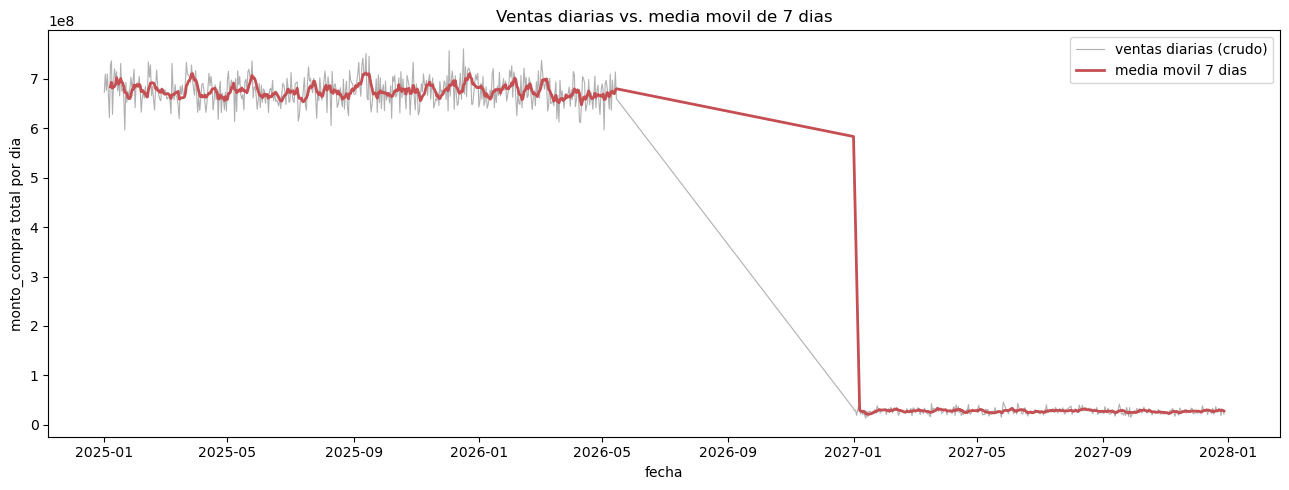

In [13]:
serie_diaria = (df_tratado.dropna(subset=['fecha_pedido'])
                .groupby(df_tratado['fecha_pedido'].dt.date)['monto_compra']
                .sum())
serie_diaria.index = pd.to_datetime(serie_diaria.index)
media_movil_7d = serie_diaria.rolling(7).mean()

print(f"Dias con datos: {len(serie_diaria):,}  ({serie_diaria.index.min().date()} a {serie_diaria.index.max().date()})")
print(f"Desviacion estandar de la serie diaria cruda: {serie_diaria.std():,.0f}")
print(f"Desviacion estandar de la media movil de 7 dias: {media_movil_7d.std():,.0f}")

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(serie_diaria.index, serie_diaria.values, color='#B0B0B0', linewidth=0.8, label='ventas diarias (crudo)')
ax.plot(media_movil_7d.index, media_movil_7d.values, color='#C44E52', linewidth=2, label='media movil 7 dias')
ax.set_xlabel('fecha')
ax.set_ylabel('monto_compra total por dia')
ax.set_title('Ventas diarias vs. media movil de 7 dias')
ax.legend()
plt.tight_layout()
plt.show()

## Etapa 3: Escalado de variables numéricas

La Etapa 2 entrega `df_tratado`, que a partir de aquí pasa a llamarse `df` para seguir la cadena.

El escalado sí aprende de los datos, porque cada escalador guarda la media, la mediana o el rango intercuartílico de la columna. Por eso se divide primero en entrenamiento y prueba, y cada escalador se ajusta únicamente con el entrenamiento.

In [14]:
df = df_tratado

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler

variables_escaladas = [
    'precio_unitario', 'unidades_vendidas', 'monto_compra',
    'edad_cliente', 'peso_pedido_kg'
]
print(f"Etapa 3 arranca con {len(df):,} filas y {df.shape[1]} columnas")

Etapa 3 arranca con 551,790 filas y 27 columnas


In [15]:
train_indices, test_indices = train_test_split(
    df.index, test_size=0.20, random_state=RANDOM_STATE
)
X_train = df.loc[train_indices, variables_escaladas]
X_test = df.loc[test_indices, variables_escaladas]

configuracion_escaladores = {
    'precio_unitario': StandardScaler(),
    'unidades_vendidas': RobustScaler(),
    'monto_compra': RobustScaler(),
    'edad_cliente': RobustScaler(),
    'peso_pedido_kg': RobustScaler(),
}

transformaciones = {}
train_escalado = pd.DataFrame(index=X_train.index)
test_escalado = pd.DataFrame(index=X_test.index)
for columna, escalador in configuracion_escaladores.items():
    escalador.fit(X_train[[columna]])
    transformaciones[columna] = escalador
    nombre = f'{columna}_escalada'
    train_escalado[nombre] = escalador.transform(X_train[[columna]]).ravel()
    test_escalado[nombre] = escalador.transform(X_test[[columna]]).ravel()

print(f'Train: {len(train_indices):,} filas | prueba: {len(test_indices):,} filas')
print('Ajuste realizado solo sobre train para:', ', '.join(transformaciones))
train_escalado.describe().T[['mean', 'std', 'min', 'max']]

Train: 441,432 filas | prueba: 110,358 filas
Ajuste realizado solo sobre train para: precio_unitario, unidades_vendidas, monto_compra, edad_cliente, peso_pedido_kg


,mean,std,min,max
precio_unitario_escalada,1.184689e-17,1.000001,-1.691817,2.863868
unidades_vendidas_escalada,9.193330e-01,1.162599,0.000000,4.000000
monto_compra_escalada,3.129914e-01,1.023403,-0.821588,7.102944
edad_cliente_escalada,5.814303e-02,0.925526,-1.677419,4.935484
peso_pedido_kg_escalada,1.542547e+01,67.774493,-1.000000,375.189189


In [16]:
df_salida = df.copy()
for columna in variables_escaladas:
    nombre = f'{columna}_escalada'
    df_salida[nombre] = np.nan
    df_salida.loc[train_escalado.index, nombre] = train_escalado[nombre]
    df_salida.loc[test_escalado.index, nombre] = test_escalado[nombre]

assert df_salida.index.equals(df.index)
assert df_salida[[f'{c}_escalada' for c in variables_escaladas]].notna().all().all()
print(f"Etapa 3 cierra con {df_salida.shape[0]:,} filas y {df_salida.shape[1]} columnas")
df_salida[variables_escaladas + [f'{c}_escalada' for c in variables_escaladas]].head()

Etapa 3 cierra con 551,790 filas y 32 columnas


,precio_unitario,unidades_vendidas,monto_compra,edad_cliente,peso_pedido_kg,precio_unitario_escalada,unidades_vendidas_escalada,monto_compra_escalada,edad_cliente_escalada,peso_pedido_kg_escalada
0,28700.0,1,28700.0,32,14.9,-1.621770,0.0,-0.798573,-0.483871,0.864865
1,195700.0,2,391400.0,73,12.9,-0.761623,1.0,-0.151472,0.838710,0.324324
2,322900.0,1,322900.0,45,9.5,-0.106470,0.0,-0.273684,-0.064516,-0.594595
3,222400.0,1,222400.0,60,12.3,-0.624103,0.0,-0.452988,0.419355,0.162162
4,626800.0,2,1253600.0,33,12.7,1.458791,1.0,1.386798,-0.451613,0.270270


## Etapa 4: Codificación de variables categóricas

La Etapa 3 entrega `df_salida`, que aquí vuelve a llamarse `df`.

Cada columna categórica recibe la técnica que corresponde a su naturaleza. Las nominales de baja cardinalidad van a one-hot, la ordinal va a ordinal encoding con el orden real definido a mano, y la de mayor cardinalidad va a target encoding.

In [17]:
df = df_salida

df_codificado = pd.get_dummies(
    df,
    columns=["categoria_producto", "metodo_pago", "canal_compra"],
    prefix=["cat", "pago", "canal"],
)
[c for c in df_codificado.columns if c.startswith(("cat_", "pago_", "canal_"))]

['cat_Belleza',
 'cat_Deportes',
 'cat_Electronica',
 'cat_Hogar',
 'cat_Jugueteria',
 'cat_Moda',
 'pago_Efectivo',
 'pago_PayPal',
 'pago_Tarjeta',
 'pago_Transferencia',
 'canal_App',
 'canal_Marketplace',
 'canal_Tienda',
 'canal_Web']

`nivel_lealtad` tiene un orden real de negocio, así que la lista `orden_lealtad` se define explícitamente. Si se dejara el orden alfabético quedaría Bronce en 0, Oro en 1, Plata en 2 y Platino en 3, que no es el orden del programa de lealtad.

In [18]:
orden_lealtad = ["Bronce", "Plata", "Oro", "Platino"]

from sklearn.preprocessing import OrdinalEncoder

codificador_lealtad = OrdinalEncoder(categories=[orden_lealtad])
df_codificado["nivel_lealtad_cod"] = codificador_lealtad.fit_transform(df_codificado[["nivel_lealtad"]])

df_codificado[["nivel_lealtad", "nivel_lealtad_cod"]].drop_duplicates().sort_values("nivel_lealtad_cod")

,nivel_lealtad,nivel_lealtad_cod
1,Bronce,0.0
3,Plata,1.0
5,Oro,2.0
0,Platino,3.0


El target encoding sí aprende de los datos, porque calcula el promedio de `monto_compra` por ciudad. Por eso se divide antes y el codificador se ajusta solo con el entrenamiento. Este es el error que hay que evitar, el mismo del caso de Camilo Duarte.

In [19]:
df_entrenamiento, df_prueba = train_test_split(df_codificado, test_size=0.2, random_state=RANDOM_STATE)
len(df_entrenamiento), len(df_prueba), len(df_codificado)

(441432, 110358, 551790)

El target encoding usa la librería `category_encoders`, que la primera celda del notebook ya instaló si faltaba.

In [20]:
from category_encoders import TargetEncoder

codificador_ciudad = TargetEncoder(cols=["ciudad_tienda"], smoothing=10)
codificador_ciudad.fit(df_entrenamiento["ciudad_tienda"], df_entrenamiento["monto_compra"])

TargetEncoder(cols=['ciudad_tienda'])

In [21]:
df_entrenamiento["ciudad_tienda_cod"] = codificador_ciudad.transform(df_entrenamiento["ciudad_tienda"])
df_prueba["ciudad_tienda_cod"] = codificador_ciudad.transform(df_prueba["ciudad_tienda"])

print("Nulos en ciudad_tienda_cod, entrenamiento:", df_entrenamiento["ciudad_tienda_cod"].isnull().sum())
print("Nulos en ciudad_tienda_cod, prueba:", df_prueba["ciudad_tienda_cod"].isnull().sum())
df_entrenamiento["ciudad_tienda_cod"].describe()

Nulos en ciudad_tienda_cod, entrenamiento: 0
Nulos en ciudad_tienda_cod, prueba: 0


count    441432.000000
mean     651731.697294
std        1712.545815
min      648696.047794
25%      650035.323070
50%      651986.395160
75%      652396.660118
max      654635.675460
Name: ciudad_tienda_cod, dtype: float64

In [22]:
df = pd.concat([df_entrenamiento, df_prueba]).sort_index()
print(f"Etapa 4 cierra con {df.shape[0]:,} filas y {df.shape[1]} columnas")
df.shape

Etapa 4 cierra con 551,790 filas y 45 columnas


(551790, 45)

## Etapa 5: Transformaciones de fecha, texto y discretización

`fecha_pedido` ya quedó como fecha real desde la Etapa 1. Como en el pipeline nunca pasa por un CSV intermedio, conserva su tipo, y esta celda solo lo confirma antes de extraer las variables temporales.

In [23]:
df["fecha_pedido"] = pd.to_datetime(df["fecha_pedido"], errors="coerce")
df["fecha_pedido"].dtype, df["fecha_pedido"].isnull().sum()

(dtype('<M8[ns]'), np.int64(19583))

In [24]:
df["mes_pedido"] = df["fecha_pedido"].dt.month
df["trimestre_pedido"] = df["fecha_pedido"].dt.quarter
df["dia_semana_pedido"] = df["fecha_pedido"].dt.day_name()
df["es_fin_semana_pedido"] = df["fecha_pedido"].dt.dayofweek >= 5

df[["fecha_pedido", "mes_pedido", "trimestre_pedido", "dia_semana_pedido", "es_fin_semana_pedido"]].head()

,fecha_pedido,mes_pedido,trimestre_pedido,dia_semana_pedido,es_fin_semana_pedido
0,2025-11-15,11.0,4.0,Saturday,True
1,2026-03-05,3.0,1.0,Thursday,False
2,2025-06-27,6.0,2.0,Friday,False
3,2025-05-01,5.0,2.0,Thursday,False
4,2025-08-29,8.0,3.0,Friday,False


Los comentarios vacíos se rellenan con texto vacío antes de medir nada, para que la longitud y el conteo de palabras no queden en nulo.

In [25]:
df["comentario_cliente"] = df["comentario_cliente"].fillna("")

df["longitud_comentario"] = df["comentario_cliente"].str.len()
df["num_palabras_comentario"] = df["comentario_cliente"].str.split().str.len()
df["tiene_comentario"] = ~df["comentario_cliente"].isin(["", "Sin comentario"])
df["menciona_demora"] = df["comentario_cliente"].str.contains("demor|tard|retras", case=False, na=False)

df[["comentario_cliente", "longitud_comentario", "num_palabras_comentario", "tiene_comentario", "menciona_demora"]].head()

,comentario_cliente,longitud_comentario,num_palabras_comentario,tiene_comentario,menciona_demora
0,El domiciliario fue muy amable,30,5,True,False
1,El producto llegó dañado,24,4,True,False
2,Rápido y sin problemas,22,4,True,False
3,Sin comentario,14,2,False,False
4,Llegó incompleto el pedido,26,4,True,False


Los límites de `grupo_edad` son reglas fijas del negocio, no un cálculo aprendido de los datos, así que la discretización se aplica sobre el dataset completo sin riesgo de fuga.

In [26]:
df["grupo_edad"] = pd.cut(
    df["edad_cliente"],
    bins=[17, 25, 35, 45, 60, 100],
    labels=["18 a 25", "26 a 35", "36 a 45", "46 a 60", "61 y más"],
)
df["grupo_edad"].value_counts(dropna=False).sort_index()

grupo_edad
18 a 25      71594
26 a 35      89606
36 a 45      89369
46 a 60     134949
61 y más    134314
NaN          31958
Name: count, dtype: int64

Hay clientes con `edad_cliente` fuera del rango 18 a 100, con edades negativas o mayores a 100. Es un problema de exactitud ya señalado desde la auditoría de calidad de la Semana 3. Esas filas quedan con `grupo_edad` vacío porque caen fuera de los bins de negocio. No se fuerzan dentro de un grupo porque no se sabe cuál sería su edad real.

Con `grupo_edad` ya creada se vuelve a dividir, usando el mismo `random_state`, para que las dos particiones incluyan la columna nueva.

In [27]:
df_entrenamiento, df_prueba = train_test_split(df, test_size=0.2, random_state=RANDOM_STATE)
"grupo_edad" in df_entrenamiento.columns, "grupo_edad" in df_prueba.columns

(True, True)

In [28]:
sesgo_original = df["monto_compra"].skew()
print(f"Sesgo original de monto_compra: {sesgo_original:.4f}")

Sesgo original de monto_compra: 2.0430


El logaritmo no aprende nada de los datos, no ajusta ningún parámetro a partir de ellos, así que aplicarlo antes o después de dividir da exactamente el mismo resultado fila por fila. Box-Cox es distinto, porque sí aprende un parámetro lambda de la distribución, y por eso se ajusta solo con el entrenamiento.

In [29]:
df_entrenamiento["monto_compra_log"] = np.log1p(df_entrenamiento["monto_compra"])
df_prueba["monto_compra_log"] = np.log1p(df_prueba["monto_compra"])

df_entrenamiento["monto_compra_log"].skew()

np.float64(-0.20245319884029103)

In [30]:
from sklearn.preprocessing import PowerTransformer

transformador_boxcox = PowerTransformer(method="box-cox")
transformador_boxcox.fit(df_entrenamiento[["monto_compra"]])

PowerTransformer(method='box-cox')

In [31]:
df_entrenamiento["monto_compra_boxcox"] = transformador_boxcox.transform(df_entrenamiento[["monto_compra"]])
df_prueba["monto_compra_boxcox"] = transformador_boxcox.transform(df_prueba[["monto_compra"]])

df_entrenamiento["monto_compra_boxcox"].skew()

np.float64(-0.005346100418620022)

In [32]:
df_final = pd.concat([df_entrenamiento, df_prueba]).sort_index()
print(f"Etapa 5 cierra con {df_final.shape[0]:,} filas y {df_final.shape[1]} columnas")
df_final.shape

Etapa 5 cierra con 551,790 filas y 56 columnas


(551790, 56)

## Comparación de sesgo antes y después

In [33]:
comparacion_sesgo = pd.DataFrame({
    "variable": ["monto_compra", "monto_compra_log", "monto_compra_boxcox"],
    "sesgo": [
        df_final["monto_compra"].skew(),
        df_final["monto_compra_log"].skew(),
        df_final["monto_compra_boxcox"].skew(),
    ],
})
comparacion_sesgo

,variable,sesgo
0,monto_compra,2.042959
1,monto_compra_log,-0.199733
2,monto_compra_boxcox,-0.002856


`monto_compra` original tiene un sesgo positivo marcado, con una cola larga hacia montos altos. El logaritmo ya lo reduce bastante, pero Box-Cox es el que más lo acerca a cero, porque busca automáticamente el parámetro lambda que mejor normaliza esta distribución específica en vez de aplicar una transformación fija.

## Verificación del pipeline completo

Control final antes de exportar. Se revisa que no queden duplicados y que estén presentes las columnas que aporta cada una de las cinco etapas.

In [34]:
columnas_por_etapa = {
    "Etapa 2, atipicos": ["es_venta_corporativa", "monto_compra_capado"],
    "Etapa 3, escalado": [f"{c}_escalada" for c in variables_escaladas],
    "Etapa 4, codificacion": (
        [c for c in df_final.columns if c.startswith(("cat_", "pago_", "canal_"))]
        + ["nivel_lealtad_cod", "ciudad_tienda_cod"]
    ),
    "Etapa 5, transformaciones": [
        "mes_pedido", "trimestre_pedido", "dia_semana_pedido", "es_fin_semana_pedido",
        "longitud_comentario", "num_palabras_comentario", "tiene_comentario", "menciona_demora",
        "grupo_edad", "monto_compra_log", "monto_compra_boxcox",
    ],
}

for etapa, columnas in columnas_por_etapa.items():
    faltantes = [c for c in columnas if c not in df_final.columns]
    assert not faltantes, f"{etapa} dejo columnas faltantes: {faltantes}"
    print(f"{etapa}: {len(columnas)} columnas presentes")

duplicados_finales = df_final.duplicated().sum()
assert duplicados_finales == 0, "El dataset final tiene duplicados"
print(f"\nDuplicados exactos en el dataset final: {duplicados_finales}")
print(f"Dataset final: {df_final.shape[0]:,} filas y {df_final.shape[1]} columnas")

Etapa 2, atipicos: 2 columnas presentes
Etapa 3, escalado: 5 columnas presentes
Etapa 4, codificacion: 16 columnas presentes
Etapa 5, transformaciones: 11 columnas presentes

Duplicados exactos en el dataset final: 0
Dataset final: 551,790 filas y 56 columnas


## Diccionario de datos

La Etapa 1 no crea columnas nuevas. Corrige las que ya existían, normalizando el texto, convirtiendo `fecha_pedido` a fecha real y eliminando duplicados. Las demás etapas sí agregan columnas, y son las que se describen aquí.

| Columna del dataset | De qué semana viene | Qué significa |
|---|---|---|
| `es_venta_corporativa` | Semana 7 | Marca los pedidos de monto alto que se conservaron a propósito, porque venden 4 o 5 unidades y se comportan como compras corporativas reales en vez de errores de captura |
| `monto_compra_capado` | Semana 7 | Indica si a esa fila se le recortó el monto hasta el límite superior del IQR durante el winsorizing |
| `precio_unitario_escalada` | Semana 8 | Precio unitario llevado a escala estándar con StandardScaler, ajustado solo con el conjunto de entrenamiento |
| `unidades_vendidas_escalada` | Semana 8 | Unidades vendidas en escala robusta, centrada en la mediana y dividida por el rango intercuartílico |
| `monto_compra_escalada` | Semana 8 | Monto de compra en escala robusta, menos sensible que la estándar a los montos altos que se conservaron |
| `edad_cliente_escalada` | Semana 8 | Edad del cliente en escala robusta |
| `peso_pedido_kg_escalada` | Semana 8 | Peso del pedido en escala robusta |
| `cat_Belleza`, `cat_Deportes`, `cat_Electronica`, `cat_Hogar`, `cat_Jugueteria`, `cat_Moda` | Semana 9 | Seis columnas binarias del one-hot de `categoria_producto`. Cada una vale 1 cuando el pedido pertenece a esa categoría |
| `pago_Efectivo`, `pago_PayPal`, `pago_Tarjeta`, `pago_Transferencia` | Semana 9 | Cuatro columnas binarias del one-hot de `metodo_pago` |
| `canal_App`, `canal_Marketplace`, `canal_Tienda`, `canal_Web` | Semana 9 | Cuatro columnas binarias del one-hot de `canal_compra` |
| `nivel_lealtad_cod` | Semana 9 | Nivel de lealtad como número que respeta el orden real del programa, con Bronce en 0, Plata en 1, Oro en 2 y Platino en 3 |
| `ciudad_tienda_cod` | Semana 9 | Target encoding de `ciudad_tienda`. Resume cada ciudad en un promedio suavizado de `monto_compra` aprendido únicamente con el conjunto de entrenamiento |
| `mes_pedido` | Semana 10 | Número de mes en que se hizo el pedido, de 1 a 12 |
| `trimestre_pedido` | Semana 10 | Trimestre en que se hizo el pedido, de 1 a 4 |
| `dia_semana_pedido` | Semana 10 | Nombre del día de la semana en que se hizo el pedido |
| `es_fin_semana_pedido` | Semana 10 | Vale True cuando el pedido cayó sábado o domingo |
| `longitud_comentario` | Semana 10 | Cantidad de caracteres del comentario del cliente |
| `num_palabras_comentario` | Semana 10 | Cantidad de palabras del comentario del cliente |
| `tiene_comentario` | Semana 10 | Vale False cuando el comentario quedó vacío o es el texto Sin comentario que dejó la imputación de la Misión 1 |
| `menciona_demora` | Semana 10 | Vale True cuando el comentario menciona demora, tardanza o retraso |
| `grupo_edad` | Semana 10 | Edad del cliente discretizada en rangos fijos de negocio. Queda vacía en los clientes cuya edad cae fuera de 18 a 100 |
| `monto_compra_log` | Semana 10 | Logaritmo de `monto_compra` calculado con log1p, para reducir el sesgo hacia montos altos |
| `monto_compra_boxcox` | Semana 10 | Monto de compra transformado con Box-Cox, con el parámetro lambda ajustado solo con el conjunto de entrenamiento |

## Exportación del dataset final

In [ ]:
df_final.to_csv("S11_PD_PallaresArbelaezSanchez_DatasetTransformado.csv", index=False)
print("Archivo exportado: S11_PD_PallaresArbelaezSanchez_DatasetTransformado.csv")
print(f"{df_final.shape[0]:,} filas y {df_final.shape[1]} columnas")